In [1]:
# import subprocess
# import sys

# try:
#     from ultralytics import YOLO
# except ModuleNotFoundError : 
#     print("ultralytics가 설치되지 않음")

#     try:
#         subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics', 'opencv-python'])

#     except subprocess.CalledProcessError as e:
#         raise SystemExit(f"ultralytics 설치 실패 : {e}")
    
# from ultralytics import YOLO

!pip install ultralytics opencv-python

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.51 🚀 Python-3.10.20 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce MX250, 1994MiB)


Setup complete ✅ (8 CPUs, 15.4 GB RAM, 87.8/97.9 GB disk)


In [3]:
# YOLO11 모델로 이미지 감지
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
print(model.names, len(model.names))




{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [4]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CUDA 사용 불가")

import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

x = torch.rand(3, 3).cuda()
y = x @ x
print(y)

1.13.1+cu117
True
NVIDIA GeForce MX250
1.13.1+cu117
11.7
True
NVIDIA GeForce MX250
tensor([[0.6392, 0.7127, 0.7393],
        [0.4497, 0.5055, 0.3637],
        [0.3047, 0.4023, 0.5087]], device='cuda:0')


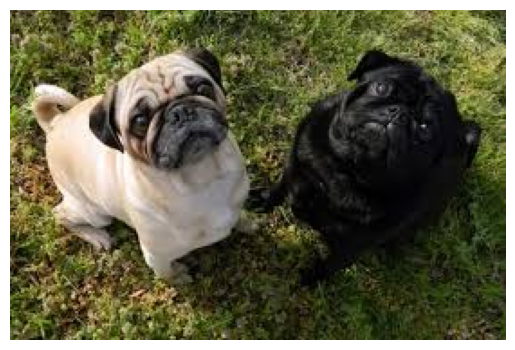


0: 448x640 2 dogs, 15.1ms
Speed: 2.0ms preprocess, 15.1ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
(183, 275)
image.shape :  (183, 275, 3)
image[0, 0] :  [70 61 30]


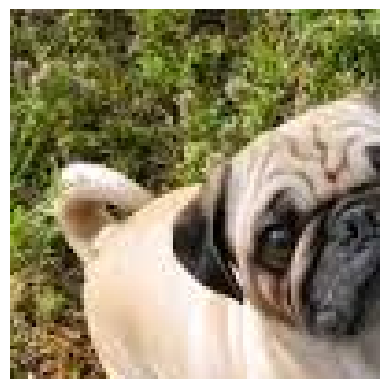

In [10]:
# 이미지 로딩 후 감지
from PIL import Image
import matplotlib.pyplot as plt
import sys

image_path = "./yolo_imgs/dog.jpg"

try:
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
except Exception as e:
    print("load err : ", e)
    sys.exit()

# 객체 감지
import cv2
import numpy as np

try:
    results = model(img)
    print(results[0].orig_shape)

except Exception as e:
    print("detect err : ", e)
    sys.exit()

image = np.array(img)
print("image.shape : ", image.shape)
print("image[0, 0] : ", image[0,0])

# 이미지 영역 자르기
cropped = image[:100, :100]
plt.imshow(cropped)
plt.axis("off")
plt.show()

In [ ]:
# dog 이미지에 박스 채우기
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

dog_detected = False            # dog 감지 여부 판단용 함수

for result in results:
    try:
        # 감지된 객체들의 바운딩 박스 리스트
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            print(x1, y1, x2, y2)

            label = result.names[int(box.cls[0])]
            print(label)

            dog_detected = True
    except Exception as e:
        print("process err : ", e)
    
print("dog detected : ", dog_detected)


error: OpenCV(4.10.0) /io/opencv/modules/imgproc/src/demosaicing.cpp:1723: error: (-215:Assertion failed) scn == 1 && (dcn == 3 || dcn == 4) in function 'demosaicing'
